# SARIMA(p,d,q)(P,D,Q)m
# 季節性自迴歸整合移動平均模型
我們終於來到時間序列分析中最有趣的部分之一：季節性。

ARIMA 接受參數 $(p,d,q)$，而 SARIMA 接受 <em>額外</em> 一組參數 $(P,D,Q)m$，這些參數專門描述模型的季節性部分。這裡的 $P$、$D$ 和 $Q$ 分別代表季節性回歸、差分和移動平均係數，$m$ 代表每個季節週期中的數據點（行）數。

安裝套件
conda install -c conda-forge pmdarima|

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [9]:
import pandas as pd
import numpy as np

# Load specific forecasting tools
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf # for determining (p,q) orders
from statsmodels.tsa.seasonal import seasonal_decompose      # for ETS Plots

In [3]:
df = pd.read_csv("co2_mm_mlo.csv")
df.head()

,year,month,decimal_date,average,interpolated
0,1958,3,1958.208,315.71,315.71
1,1958,4,1958.292,317.45,317.45
2,1958,5,1958.375,317.50,317.50
3,1958,6,1958.458,NaN,317.10
4,1958,7,1958.542,315.86,315.86


In [ ]:
df["date"] = pd.to_datetime(dict(year=df["year"],month=df["month"],day=1))
df.head()


,year,month,decimal_date,average,interpolated,date
0,1958,3,1958.208,315.71,315.71,1958-03-01
1,1958,4,1958.292,317.45,317.45,1958-04-01
2,1958,5,1958.375,317.50,317.50,1958-05-01
3,1958,6,1958.458,NaN,317.10,1958-06-01
4,1958,7,1958.542,315.86,315.86,1958-07-01


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 729 entries, 0 to 728
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   year          729 non-null    int64         
 1   month         729 non-null    int64         
 2   decimal_date  729 non-null    float64       
 3   average       722 non-null    float64       
 4   interpolated  729 non-null    float64       
 5   date          729 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(3), int64(2)
memory usage: 34.3 KB


In [6]:
df.set_index("date",inplace=True)
df.index.freq = "MS"
df.head()

,year,month,decimal_date,average,interpolated
date,,,,,
1958-03-01,1958,3,1958.208,315.71,315.71
1958-04-01,1958,4,1958.292,317.45,317.45
1958-05-01,1958,5,1958.375,317.50,317.50
1958-06-01,1958,6,1958.458,NaN,317.10
1958-07-01,1958,7,1958.542,315.86,315.86


[Text(0.5, 0, ''), Text(0, 0.5, 'parts per million')]

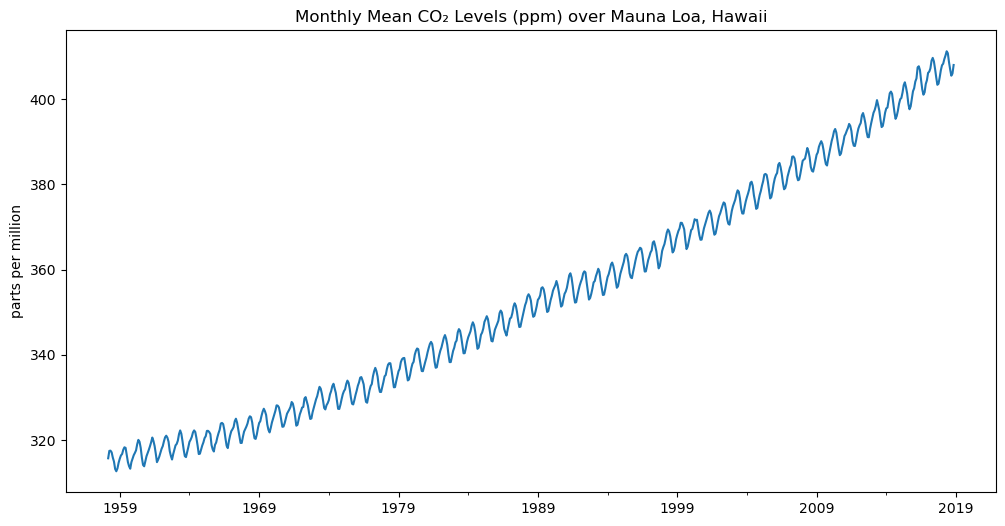

In [7]:
title = 'Monthly Mean CO₂ Levels (ppm) over Mauna Loa, Hawaii'
ylabel='parts per million'
xlabel=''
ax = df["interpolated"].plot(figsize=(12,6),title=title)
ax.autoscale(axis="x")
ax.set(xlabel=xlabel,ylabel=ylabel)

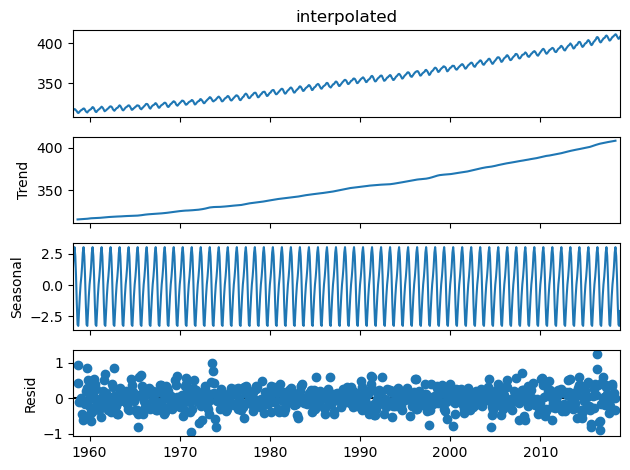

In [ ]:
import matplotlib.pyplot as plt
result = seasonal_decompose(df["interpolated"])
result.plot()
plt.show()

In [10]:
from pmdarima import auto_arima 
auto_arima(df["interpolated"],seasonal=True,m=12).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  729
Model:             SARIMAX(2, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -206.365
Date:                            Wed, 10 Jun 2026   AIC                            424.730
Time:                                    19:42:18   BIC                            452.272
Sample:                                03-01-1958   HQIC                           435.357
                                     - 11-01-2018                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3856      0.082      4.687      0.000       0.224       0.547
ar.L2          0.0995      0.024      4.221      0.000       0.053       0.146
ma.L1         -0.7349      0.065    -11.230      0.000      -0.863      -0.607
ar.S.L12       0.9996      0.000   2549.029      0.000       0.999       1.000
ma.S.L12      -0.8657      0.022    -40.157      0.000      -0.908      -0.823
sigma2         0.0959      0.005     20.621      0.000       0.087       0.105
===================================================================================
Ljung-Box (L1) (Q):                   0.14   Jarque-Bera (JB):                 4.26
Prob(Q):                              0.71   Prob(JB):                         0.12
Heteroskedasticity (H):               1.12   Skew:                             0.00
Prob(H) (two-sided):                  0.36   Kurtosis:                         3.37
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [11]:
#	SARIMAX(2, 1, 1)x(1, 0, 1, 12)	
train = df.iloc[:717]
test = df.iloc[717:]
model = SARIMAX(train["interpolated"],order=(2, 1, 1),seasonal_order=(1, 0, 1, 12))
result = model.fit()

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [19]:
start = len(train)
end = start+len(test)-1
#dynamic=False
#猜後天 是拿預測明天 還是拿實際的明天 
#dynamic=False 拿實際的明天 
predictions = result.get_prediction(start=start,end=end,dynamic=False)
# 取出真正的預測平均值
pred_mean = predictions.predicted_mean
# 很重要：讓預測資料的 index 跟 test 一樣
pred_mean.index = test.index


[Text(0.5, 0, ''), Text(0, 0.5, 'parts per million')]

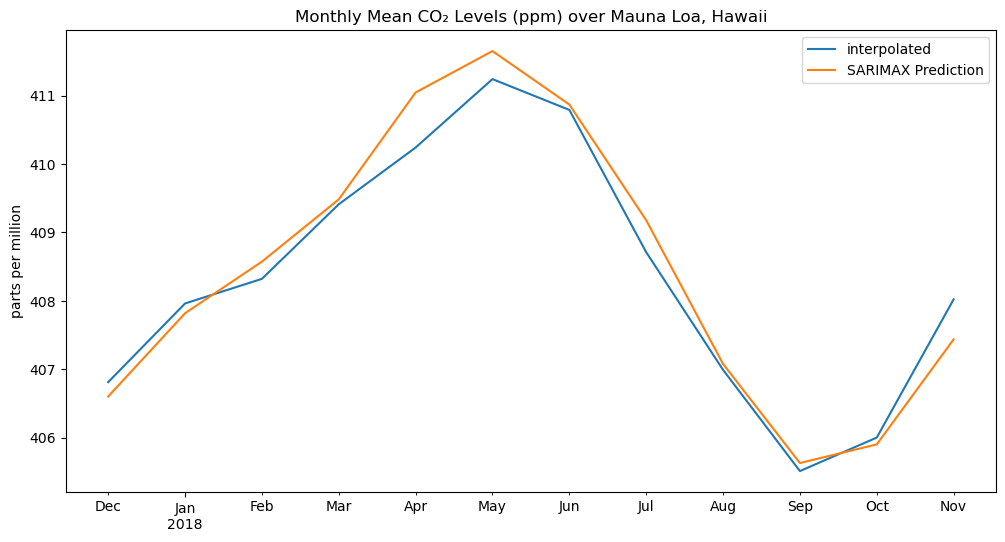

In [20]:
title = 'Monthly Mean CO₂ Levels (ppm) over Mauna Loa, Hawaii'
ylabel='parts per million'
xlabel=''
ax = test["interpolated"].plot(legend=True,figsize=(12,6),title=title)
pred_mean.plot(
    ax=ax,
    legend=True,
    label="SARIMAX Prediction"
)
ax.autoscale(axis="x")
ax.set(xlabel=xlabel,ylabel = ylabel)

## 梯度下降練習
Wt+1 = Wt  - learning rate * gradient

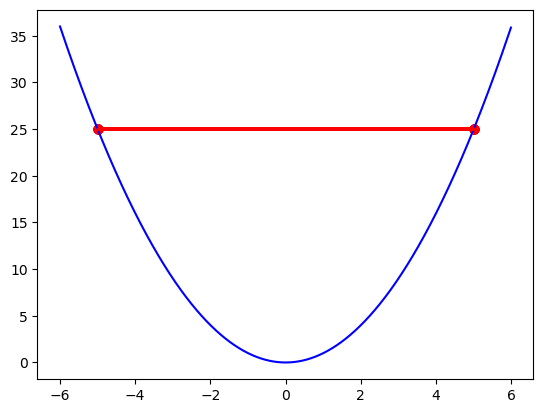

In [ ]:
import numpy as np

import matplotlib.pyplot as plt

def func(x):return x ** 2
def dfunc(x):return 2 *ｘ

def GD(x_start,df,epochs,lr):
    """  梯度下降法。給定起始點與目標函數的一階導函數，求在epochs次反覆運算中x的更新值
        :param x_start: x的起始點    
        :param df: 目標函數的一階導函數    
        :param epochs: 反覆運算週期    
        :param lr: 學習率    
        :return: x在每次反覆運算後的位置（包括起始點），長度為epochs+1    
    """   
    xs = np.zeros(epochs + 1) 
    w = x_start
    xs[0] = w
    for i in range(epochs):
        dx = df(w)
        w += -dx * lr
        xs[i+1] = w
    return xs
x_start = 5
epochs = 5
lr = 0.01
w  = GD(x_start,dfunc,epochs,lr)
color = "r"
import numpy as np
t = np.arange(-6.0,6.0,0.01)
plt.plot(t,func(t),c="b")    
plt.plot(w,func(w),c=color,label=f"lr:{lr}")
plt.scatter(w,func(w),c=color)
#plt.plot()

In [27]:
y_true = [0, 0, 0, 1, 1, 1, 1, 1]
y_pred = [0, 1, 0, 1, 0, 1, 0, 1]

In [28]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_true, y_pred)

array([[2, 1],
       [2, 3]])

In [30]:
confusion_matrix(y_true, y_pred,labels=[1,0])

array([[3, 2],
       [1, 2]])

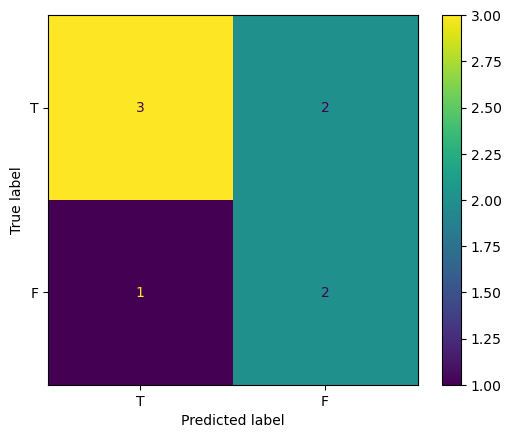

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(y_true,y_pred,labels=[1,0],display_labels=["T","F"])